# Proyek Analisis Data: E-Commerce
- **Nama:** Ekananda Naufal Arif Wicaksana
- **Email:** naufallwcksn@gmail.com
- **ID Dicoding:** CDCC183D6Y2712

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Bagaimana tren total penjualan dan jumlah order pada setiap bulan selama periode dataset, serta kapan terjadi peningkatan atau penurunan yang signifikan?
- Pertanyaan 2: Bagaimana distribusi rating pelanggan dan bagaimana perbedaannya berdasarkan status order dalam periode dataset?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

####Load orders_dataset

In [2]:
order_df = pd.read_csv('https://raw.githubusercontent.com/Naufallwcksn/submission/refs/heads/main/data/orders_dataset.csv')
order_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:**
- Mengetahui 5 baris pertama dari orders_dataset.csv

####Load order_items_dataset

In [3]:
items_order_df = pd.read_csv('https://raw.githubusercontent.com/Naufallwcksn/submission/refs/heads/main/data/order_items_dataset.csv')
items_order_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


**Insight:**
- Megetahui 5 baris pertama dari dataset order_items_dataset.csv

####Load order_reviews_dataset

In [4]:
reviews_order_df = pd.read_csv('https://raw.githubusercontent.com/Naufallwcksn/submission/refs/heads/main/data/order_reviews_dataset.csv')
reviews_order_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


**Insight:**
- Mengetahui 5 baris pertama dari order_reviews_dataset.csv

####Load order_payments_dataset

In [5]:
payments_order_df = pd.read_csv('https://raw.githubusercontent.com/Naufallwcksn/submission/refs/heads/main/data/order_payments_dataset.csv')
payments_order_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


**Insight:**
- Mengetahui 5 baris pertama dari order_payments_dataset_csv

### Assessing Data

####Menilai data order_df

In [6]:
order_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [7]:
order_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [8]:
print('Jumlah duplikasi: ', order_df.duplicated().sum())

Jumlah duplikasi:  0


In [9]:
print('Jumlah duplikasi: ', order_df.duplicated(subset=['order_id']).sum())

Jumlah duplikasi:  0


In [10]:
order_df.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [11]:
order_df['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [12]:
(order_df['order_delivered_customer_date'] < order_df['order_purchase_timestamp']).sum()

np.int64(0)

**Insight:**
- dapat dilihat bahwa orders_dataset memiliki 99441 baris dan 8 kolom dan semuanya memiliki tipe data object sedangkan pada kolom order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date seharusnya bertipe data datetime
- terdapat beberapa kolom yang memiliki nilai Null atau terdapat missing values
- tidak terdapat duplikasi pada orders_dataset
- terdapat 8 macam order_status

####Menilai data items_order_df

In [13]:
items_order_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [14]:
items_order_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [15]:
print('Jumlah duplikasi: ', items_order_df.duplicated().sum())

Jumlah duplikasi:  0


In [16]:
print('Jumlah duplikasi: ', items_order_df.duplicated(subset=['order_id']).sum())

Jumlah duplikasi:  13984


In [17]:
items_order_df.describe(include='all')

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


**Insight:**
- iterms_order_dataset memiliki 112650 baris dan 7 kolom dan ada bermacam-macam tipe data pada dataset tersebut seperti object, int64, dan float64
- pada dataset tersebut tidak memiliki missing value
- terdapat 13984 duplikasi ketika dilihat dari order_id dikarenakan dalam 1 pembelian user bisa sekaligus membeli banyak barang sekaligus

####Menilai data reviews_order_df

In [18]:
reviews_order_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [19]:
reviews_order_df.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [20]:
reviews_order_df.describe(include='all')

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,99224,99224,99224.000000,11568,40977,99224,99224
unique,98410,98673,NaN,4527,36159,636,98248
top,4548534449b1f572e357211b90724f1b,03c939fd7fd3b38f8485a0f95798f1f6,NaN,Recomendo,Muito bom,2017-12-19 00:00:00,2017-06-15 23:21:05
freq,3,3,NaN,423,230,463,4
mean,NaN,NaN,4.086421,NaN,NaN,NaN,NaN
std,NaN,NaN,1.347579,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN


In [21]:
print('Jumlah duplikasi: ', reviews_order_df.duplicated().sum())

Jumlah duplikasi:  0


In [22]:
print('Jumlah duplikasi: ', reviews_order_df.duplicated(subset=['review_id']).sum())

Jumlah duplikasi:  814


**Insight:**
- pada reviews_order_dataset terdapat 99224 baris dan 7 kolom dan sebagian besar bertipe data object namun ada juga yang int64
- Terdapat sangat banyak missing values pada kolom review_comment_title dan review_comment_message karena pelanggan seringkali hanya memberikan rating bintang tanpa menuliskan ulasan teks. Ditemukan juga 814 baris duplikat pada review_id
- Terdapat 814 data duplikat pada kolom review_id yang perlu dibersihkan

####Menilai data payments_order_df

In [23]:
payments_order_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [24]:
payments_order_df.isna().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [25]:
payments_order_df.describe(include='all')

,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


In [26]:
print('Jumlah duplikasi: ', payments_order_df.duplicated().sum())

Jumlah duplikasi:  0


In [27]:
print('Jumlah duplikasi: ', payments_order_df.duplicated(subset=['order_id']).sum())

Jumlah duplikasi:  4446


**Insight:**
- Terdapat 103886 baris dan 5 kolom serta terdapat berbagai tipe data yaitu object, int64, dan float64
- Tidak terdapat missing value
- Terdapat 4446 data duplikat pada order_id

### Cleaning Data

####Membersihkan Data orders_df

In [28]:
order_df['order_purchase_timestamp']=pd.to_datetime(order_df['order_purchase_timestamp'])
order_df['order_approved_at']=pd.to_datetime(order_df['order_approved_at'])
order_df['order_delivered_carrier_date']=pd.to_datetime(order_df['order_delivered_carrier_date'])
order_df['order_delivered_customer_date']=pd.to_datetime(order_df['order_delivered_customer_date'])
order_df['order_estimated_delivery_date']=pd.to_datetime(order_df['order_estimated_delivery_date'])

In [29]:
order_df['delivery_status'] = order_df['order_delivered_customer_date'].notna()

**Insight:**
- Mengubah tipe data dari beberapa kolom yang sebelumnya object menjadi datetime
- tidak menangani missing value dikarenakan menyesuaikan dengan keadaan sebenarnya seperti paket sedang dalam prosen pengiriman, belum dikirm, sudah selesai, dan dicancel
- serta menambahkan kolom baru untuk membantu proses analisis

####Membersihkan Data items_order_df

In [30]:
items_order_df['shipping_limit_date']=pd.to_datetime(items_order_df['shipping_limit_date'])

In [31]:
items_order_df['total_price'] = items_order_df['price'] + items_order_df['freight_value']

<Axes: xlabel='price'>

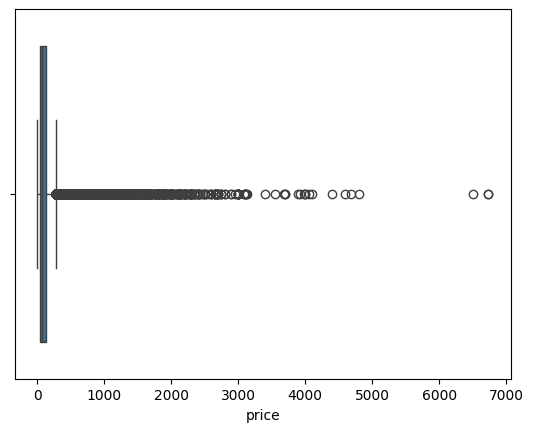

In [32]:
sns.boxplot(x=items_order_df['price'])

**Insight:**
- Mengubah tipe data dari beberapa kolom yang sebelumnya object menjadi datetime
- serta menambahkan kolom baru untuk membantu proses analisis
- terdapat banyak outlier namun itu adalah hal yang biasa dalam e-commerce karena harga barang yang mahal

####Membersihkan Data reviews_order_df

In [33]:
reviews_order_df['review_creation_date']=pd.to_datetime(reviews_order_df['review_creation_date'])
reviews_order_df['review_answer_timestamp']=pd.to_datetime(reviews_order_df['review_answer_timestamp'])

In [34]:
reviews_order_df.drop_duplicates(subset=['review_id'], inplace=True)

In [35]:
print('Jumlah duplikasi: ', reviews_order_df.duplicated(subset=['review_id']).sum())

Jumlah duplikasi:  0


**Insight:**
- Tipe data pada kolom review_creation_date dan review_answer_timestamp yang sebelumnya object diubah menjadi datetime
- Menghapus duplikasi pada kolom review_id
- Missing value tetap dibiarkan karena menggambarkan prilaku pengguna yang hanya memberi rating tanpa memberikan komentar

####Membersihkan Data payments_order_df

**Insight:**
- Tidak perlu dilakukan cleaning karena tidak terdapat missing value dan duplikasi data. Duplikasi pada order_id bersifat normal karena 1 order_id bisa melakukan 3 pembayaran.

## Exploratory Data Analysis (EDA)

### Explore order_df

In [36]:
order_df['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'delivered'),
  Text(1, 0, 'invoiced'),
  Text(2, 0, 'shipped'),
  Text(3, 0, 'processing'),
  Text(4, 0, 'unavailable'),
  Text(5, 0, 'canceled'),
  Text(6, 0, 'created'),
  Text(7, 0, 'approved')])

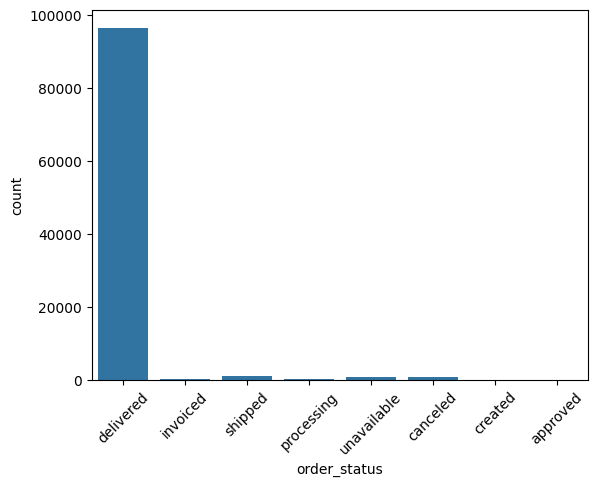

In [37]:
sns.countplot(x='order_status', data=order_df)
plt.xticks(rotation=45)

<Axes: xlabel='month'>

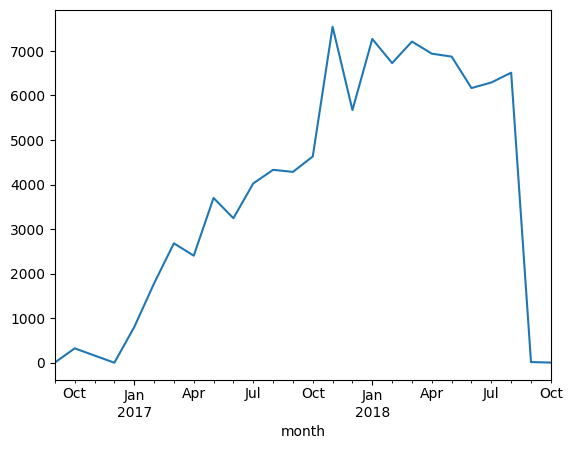

In [38]:
order_df['order_purchase_timestamp'] = pd.to_datetime(order_df['order_purchase_timestamp'])
order_df['month'] = order_df['order_purchase_timestamp'].dt.to_period('M')

order_df.groupby('month').size().plot()

**Insight:**
- Sebagian besar pesanan berstatus delivered yang berarti mayoritas pesanan berhasil diselesaikan
- jumlah pesanan mengalami fluktuasi dari waktu ke waktu

### Explore items_order_df

In [39]:
items_order_df['price'].describe()

,price
count,112650.000000
mean,120.653739
std,183.633928
min,0.850000
25%,39.900000
50%,74.990000
75%,134.900000
max,6735.000000


<Axes: xlabel='price', ylabel='Count'>

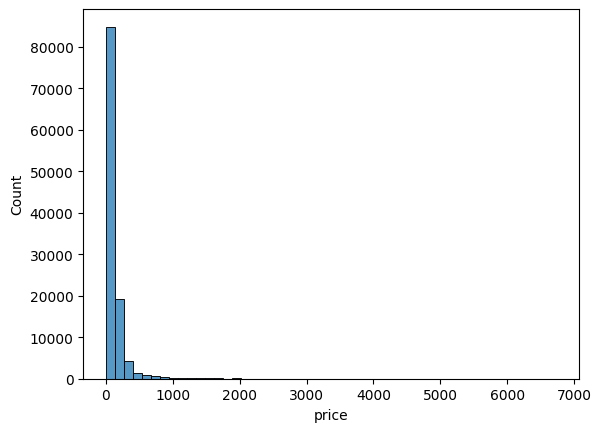

In [40]:
sns.histplot(items_order_df['price'], bins=50)

**Insight:**
- sebagian besar produk memiliki harga pada rentang tertentu dengan beberapa nilai ekstrem atau outlier

### Explore reviews_order_df

In [41]:
reviews_order_df['review_score'].value_counts()

,count
review_score,
5,56910
4,19007
1,11282
3,8097
2,3114


<Axes: xlabel='review_score', ylabel='count'>

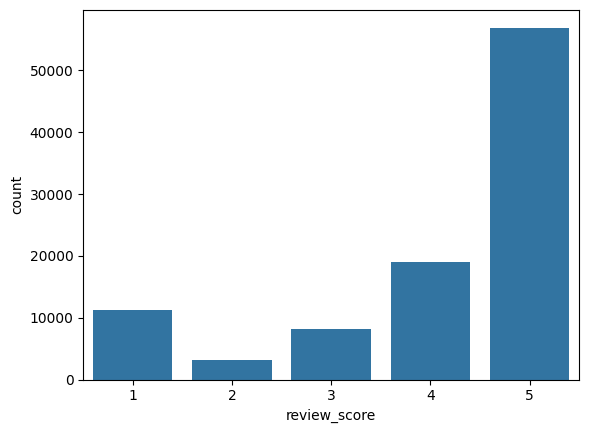

In [42]:
sns.countplot(x='review_score', data=reviews_order_df)

<Axes: xlabel='month'>

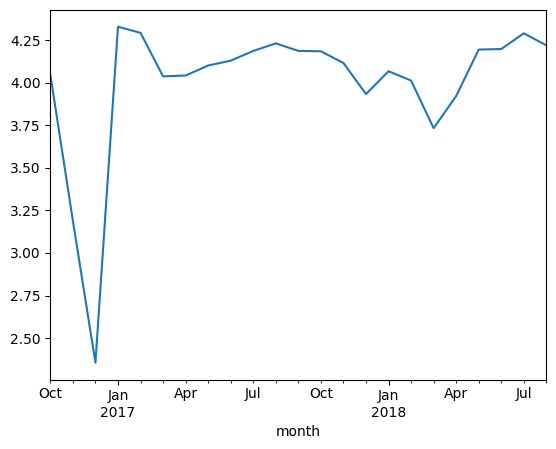

In [43]:
reviews_order_df['review_creation_date'] = pd.to_datetime(reviews_order_df['review_creation_date'])
reviews_order_df['month'] = reviews_order_df['review_creation_date'].dt.to_period('M')

reviews_order_df.groupby('month')['review_score'].mean().plot()

**Insight:**
- Sebagian pelanggan memberikan rating 4 dan 5
- rating pelanggan cenderung stabil dari waktu ke waktu

### Explore payments_order_df

In [44]:
payments_order_df['payment_type'].value_counts()

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


<Axes: xlabel='payment_type', ylabel='count'>

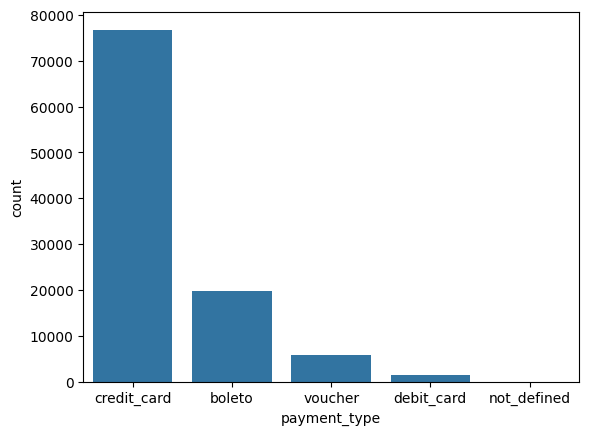

In [45]:
sns.countplot(x='payment_type', data=payments_order_df)

In [46]:
payments_order_df['payment_value'].describe()

,payment_value
count,103886.000000
mean,154.100380
std,217.494064
min,0.000000
25%,56.790000
50%,100.000000
75%,171.837500
max,13664.080000


**Insight:**
- Sebagian besar pelanggan melakukan pembayaran menggunakan kartu kredit

### Explore reviews_order_df & order_df

In [47]:
merged_df = reviews_order_df.merge(order_df, on='order_id')

**Insight:**
- menggabungkan reviews_order_df dan order_df menjadi merged_df

### Explore items_order_df & merge_df

In [48]:
merged_df = merged_df.merge(items_order_df, on='order_id')

**Insight:**
- menggabungkan merged_df dan items_order_df menjadi merged_df

### Explore payments_order_df & merge_df

In [49]:
merged_df = merged_df.merge(payments_order_df, on='order_id')

**Insight:**
- menggabungkan merged_df dan payments_order_df menjadi merged_df

### Explore merge_df

In [50]:
merged_df.groupby('order_status')['review_score'].mean()

,review_score
order_status,
approved,2.000000
canceled,1.573260
delivered,4.082734
invoiced,1.609890
processing,1.350543
shipped,1.977411
unavailable,1.571429


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'delivered'),
  Text(1, 0, 'canceled'),
  Text(2, 0, 'shipped'),
  Text(3, 0, 'processing'),
  Text(4, 0, 'invoiced'),
  Text(5, 0, 'unavailable'),
  Text(6, 0, 'approved')])

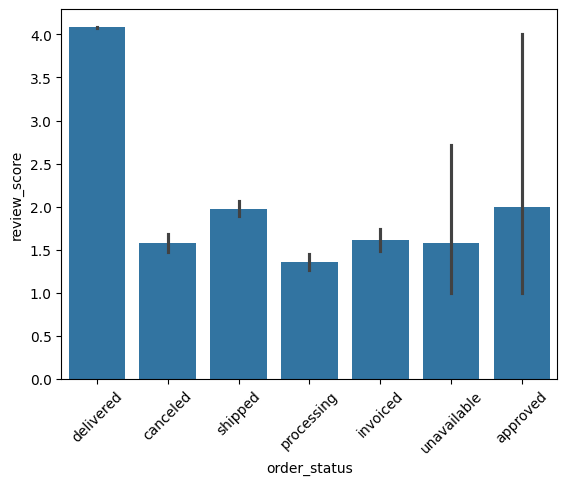

In [51]:
sns.barplot(x='order_status', y='review_score', data=merged_df)
plt.xticks(rotation=45)

<Axes: xlabel='price', ylabel='review_score'>

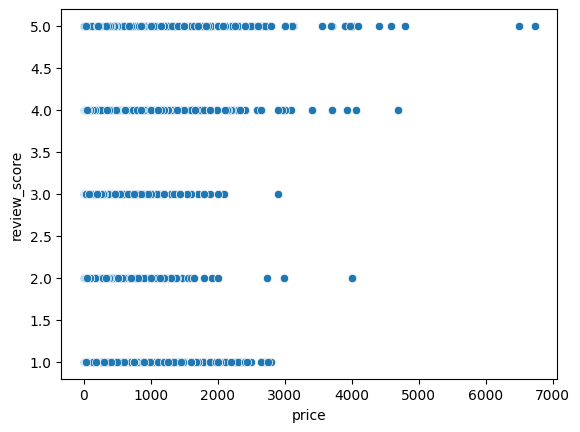

In [52]:
sns.scatterplot(x='price', y='review_score', data=merged_df)

<Axes: xlabel='freight_value', ylabel='review_score'>

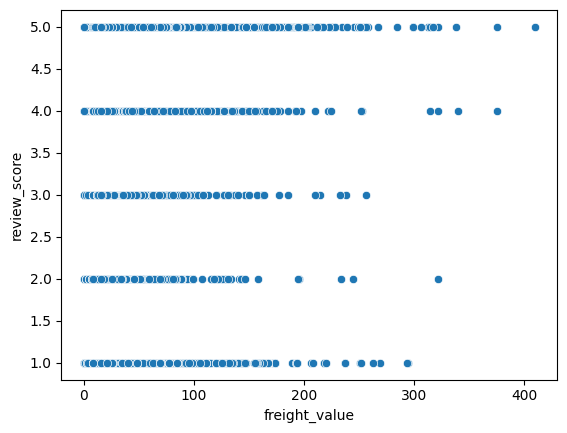

In [53]:
sns.scatterplot(x='freight_value', y='review_score', data=merged_df)

In [54]:
merged_df.groupby('payment_type')['review_score'].mean()

,review_score
payment_type,
boleto,4.026933
credit_card,4.034852
debit_card,4.157457
voucher,4.006421


([0, 1, 2, 3],
 [Text(0, 0, 'credit_card'),
  Text(1, 0, 'boleto'),
  Text(2, 0, 'voucher'),
  Text(3, 0, 'debit_card')])

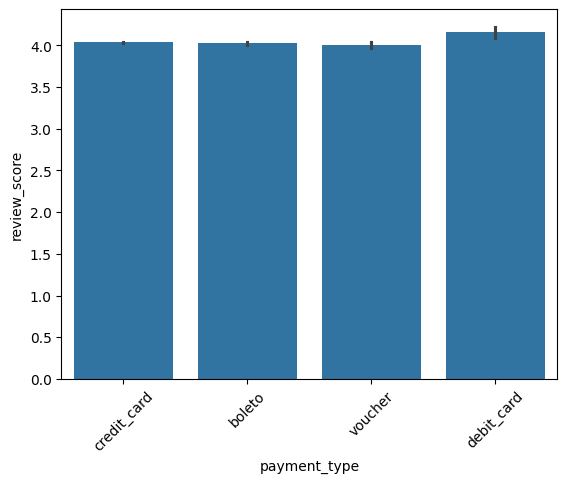

In [55]:
sns.barplot(x='payment_type', y='review_score', data=merged_df)
plt.xticks(rotation=45)

In [56]:
merged_df['delivery_time'] = (
    merged_df['order_delivered_customer_date'] -
    merged_df['order_purchase_timestamp']
).dt.days

<Axes: xlabel='delivery_time', ylabel='review_score'>

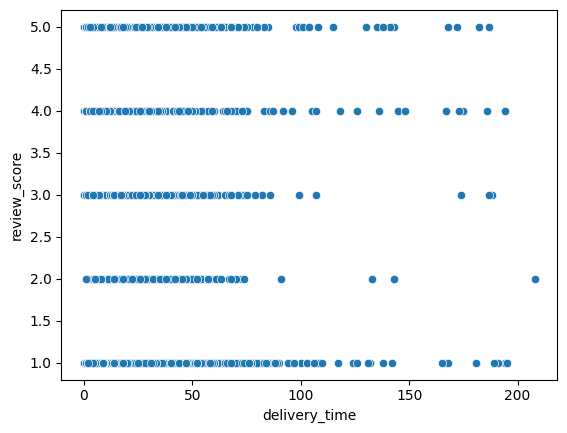

In [57]:
sns.scatterplot(x='delivery_time', y='review_score', data=merged_df)

**Insight:**
- status order memiliki pengaruh besar terhadap rating pelanggan dengan status delivered maka menghasilkan rating yang tinggi
- Harga produk dan ongkos kirim tidak menunjukan hubungan yang kuat terhadap rating
- metode pembayaran tidak berpengaruh signifikan terhadap kepuasan pelanggan
-waktu pengiriman memiliki kecenderungan mempengaruhi rating namun tidak secara kuat

## Visualization & Explanatory Analysis

### Pertanyaan 1:

In [58]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116382 entries, 0 to 116381
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   review_id                      116382 non-null  object        
 1   order_id                       116382 non-null  object        
 2   review_score                   116382 non-null  int64         
 3   review_comment_title           13849 non-null   object        
 4   review_comment_message         49316 non-null   object        
 5   review_creation_date           116382 non-null  datetime64[ns]
 6   review_answer_timestamp        116382 non-null  datetime64[ns]
 7   month_x                        116382 non-null  period[M]     
 8   customer_id                    116382 non-null  object        
 9   order_status                   116382 non-null  object        
 10  order_purchase_timestamp       116382 non-null  datetime64[ns]
 11  

In [94]:
merged_sales = order_df.merge(items_order_df, on='order_id')
merged_sales['order_purchase_timestamp'] = pd.to_datetime(merged_sales['order_purchase_timestamp'])
merged_sales['month'] = merged_sales['order_purchase_timestamp'].dt.to_period('M')

merged_sales['total_price'] = merged_sales['price'] + merged_sales['freight_value']


In [95]:
merged_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 17 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  object        
 1   customer_id                    112650 non-null  object        
 2   order_status                   112650 non-null  object        
 3   order_purchase_timestamp       112650 non-null  datetime64[ns]
 4   order_approved_at              112635 non-null  datetime64[ns]
 5   order_delivered_carrier_date   111456 non-null  datetime64[ns]
 6   order_delivered_customer_date  110196 non-null  datetime64[ns]
 7   order_estimated_delivery_date  112650 non-null  datetime64[ns]
 8   delivery_status                112650 non-null  bool          
 9   month                          112650 non-null  period[M]     
 10  order_item_id                  112650 non-null  int64         
 11  

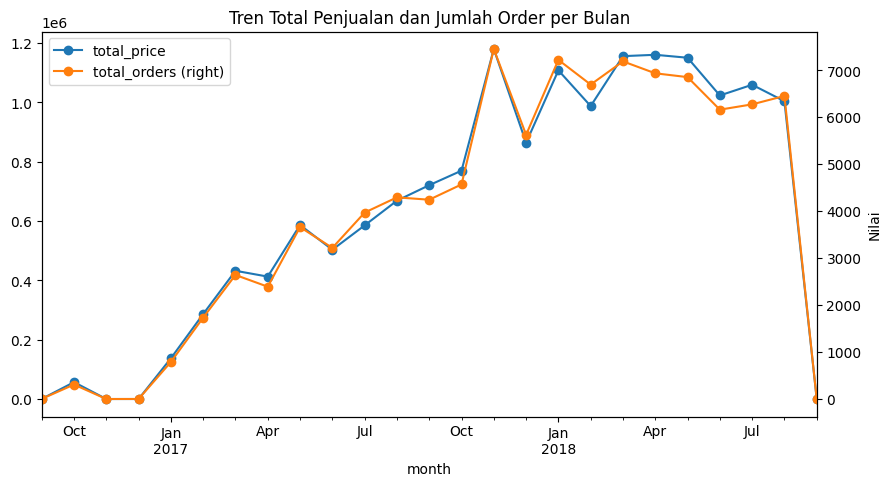

In [99]:
monthly_sales = merged_sales.groupby('month').agg({
    'total_price': 'sum',
    'order_id': 'nunique'
}).rename(columns={'order_id': 'total_orders'})

all_months = pd.period_range(start=monthly_sales.index.min(), end=monthly_sales.index.max(), freq='M')
monthly_sales = monthly_sales.reindex(all_months, fill_value=0)
monthly_sales.index.name = 'month'

monthly_sales.plot(figsize=(10,5), secondary_y='total_orders', marker='o')
plt.title('Tren Total Penjualan dan Jumlah Order per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Nilai')
plt.show()

In [100]:
print(monthly_sales.head())

         total_price  total_orders
month                             
2016-09       354.75             3
2016-10     56808.84           308
2016-11         0.00             0
2016-12        19.62             1
2017-01    137188.49           789


**Insight:**
- Tren penjualan dan jumlah order menunjukan peningkatanm signifikan dari tahun 2016 ke 2017
- kedua variabel memiliki pola yang searah atau positif
- terdapat fluktuasi bulanan namun tren keseluruhan meningkat
- Beberapa bulan dengan nilai rendah menunjukan minim atau tidak adanya transaksi

### Pertanyaan 2:

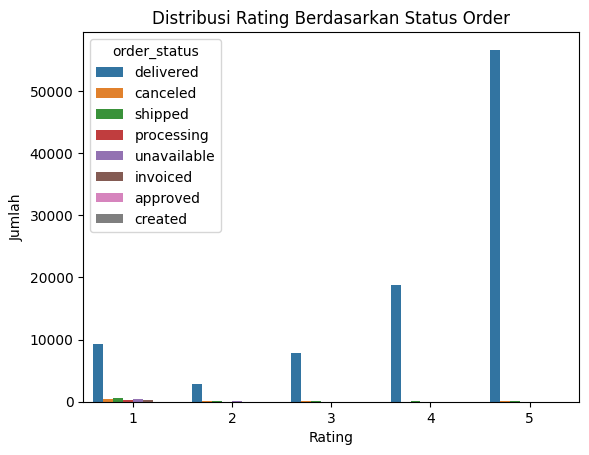

In [60]:
merged_review = reviews_order_df.merge(order_df, on='order_id')
sns.countplot(x='review_score', hue='order_status', data=merged_review)
plt.title('Distribusi Rating Berdasarkan Status Order')
plt.xlabel('Rating')
plt.ylabel('Jumlah')
plt.show()

**Insight:**
- Mayoritas pelanggan memberi rating tinggi 4-5
- Status delivered memiliki rating tertinggi
- status selain deliveredcenderung memiliki rating rendah
- Status order berpengaruh signifikan terhadap kepuasan pelanggan

## Analisis Lanjutan (Opsional)

In [101]:
merged_df[['price', 'freight_value', 'delivery_time', 'review_score']].corr()

,price,freight_value,delivery_time,review_score
price,1.000000,0.413985,0.061630,-0.004173
freight_value,0.413985,1.000000,0.213459,-0.037075
delivery_time,0.061630,0.213459,1.000000,-0.303079
review_score,-0.004173,-0.037075,-0.303079,1.000000


In [102]:
merged_df['late_delivery'] = merged_df['order_delivered_customer_date'] > merged_df['order_estimated_delivery_date']

In [103]:
merged_df.groupby('late_delivery')['review_score'].mean()

,review_score
late_delivery,
False,4.154906
True,2.546635


<Axes: xlabel='payment_type', ylabel='review_score'>

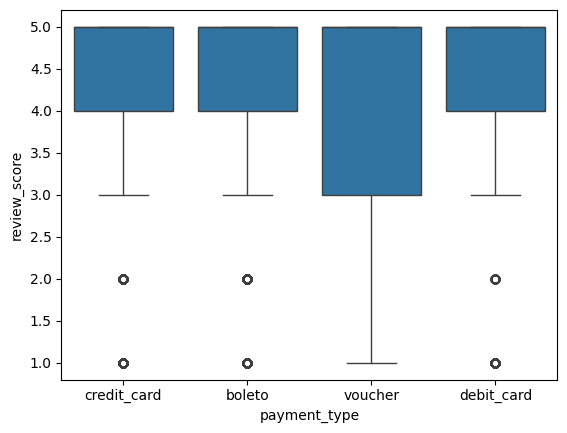

In [105]:
sns.boxplot(x='payment_type', y='review_score', data=merged_df)

## Conclusion

- Conclution pertanyaan 1: Antara tahun 2016 dan 2017, tren total penjualan dan jumlah order menunjukkan peningkatan yang signifikan, menurut analisis yang telah dilakukan. Meskipun ada perubahan selama beberapa bulan, pola secara keseluruhan menunjukkan peningkatan yang positif. Selain itu, ada hubungan positif antara jumlah order dan total penjualan, dengan peningkatan jumlah order berkontribusi langsung pada peningkatan total penjualan. Beberapa bulan dengan nilai yang sangat rendah atau tidak ada menunjukkan bahwa tidak ada transaksi selama periode tersebut.

- Conclution pertanyaan 2:
Sebagian besar rating pelanggan memiliki rating tinggi, terutama rating 4 dan 5, yang menunjukkan bahwa sebagian besar pelanggan merasa puas dengan layanan yang mereka terima. Namun, ada perbedaan besar dalam status pesanan. Pesanan dengan status delivered memiliki rating yang lebih tinggi daripada status seperti canceled, unavailable, atau processing, yang biasanya memiliki rating rendah. Ini menunjukkan bahwa penyelesaian tepat waktu pesanan pelanggan adalah komponen utama yang memengaruhi kepuasan pelanggan.

Selain itu, variabel seperti harga produk, biaya pengiriman, dan metode pembayaran tidak memiliki pengaruh yang signifikan terhadap rating pelanggan. Waktu pengiriman mungkin mempengaruhi rating, tetapi tidak secara signifikan.